# Coingecko Pipeline Example – End-to-End Pipeline (6 Tasks)

In [5]:
import luigi
from datetime import datetime, timezone
from IPython.display import Image, display
from coingecko_utils import ( 
    FetchDataTask, CleanDataTask, AnalyzeDataTask,
    VisualizeDataTask, AlertTask, StoreToS3Task
)

Using Luigi.build to execute the tasks in the pipeline

In [2]:
today = datetime.now(timezone.utc).date()
luigi.build([
    StoreToS3Task(),
    AlertTask(),
    VisualizeDataTask(),
    AnalyzeDataTask(),
    CleanDataTask(),
    FetchDataTask()
], local_scheduler=True)

DEBUG: Checking if StoreToS3Task(date=2025-05-18) is complete
INFO: Informed scheduler that task   StoreToS3Task_2025_05_18_68029ac4d8   has status   DONE
DEBUG: Checking if AlertTask(date=2025-05-18) is complete
INFO: Informed scheduler that task   AlertTask_2025_05_18_68029ac4d8   has status   DONE
DEBUG: Checking if VisualizeDataTask(date=2025-05-18) is complete
INFO: Informed scheduler that task   VisualizeDataTask_2025_05_18_68029ac4d8   has status   DONE
DEBUG: Checking if AnalyzeDataTask(date=2025-05-18) is complete
INFO: Informed scheduler that task   AnalyzeDataTask_2025_05_18_68029ac4d8   has status   DONE
DEBUG: Checking if CleanDataTask(date=2025-05-18) is complete
INFO: Informed scheduler that task   CleanDataTask_2025_05_18_68029ac4d8   has status   DONE
DEBUG: Checking if FetchDataTask(date=2025-05-18) is complete
INFO: Informed scheduler that task   FetchDataTask_2025_05_18_68029ac4d8   has status   DONE
INFO: Done scheduling tasks
INFO: Running Worker with 1 processes


True

Data after cleaning

In [3]:
import pandas as pd
cleaned = pd.read_csv(f"data/clean_{today}.csv")
cleaned.head(10)

,timestamp,price
0,2025-05-16 02:09:46.666,104095.833010
1,2025-05-16 03:04:37.759,104209.185150
2,2025-05-16 04:04:55.983,104106.845096
3,2025-05-16 05:09:53.147,103921.676389
4,2025-05-16 06:08:32.591,103957.376004
5,2025-05-16 07:04:55.010,103992.828404
6,2025-05-16 08:07:16.320,103754.424904
7,2025-05-16 09:09:52.578,103448.925587
8,2025-05-16 10:04:44.423,103745.432029
9,2025-05-16 11:08:18.896,103870.405031


Data after analysis

In [ ]:
analyzed = pd.read_csv(f"data/analyzed_{today}.csv")
analyzed.head(10)

,timestamp,price,volatility,forecast,zscore,anomaly
0,2025-05-16 02:09:46.666,104095.833010,NaN,NaN,1.553848,False
1,2025-05-16 03:04:37.759,104209.185150,NaN,NaN,1.845432,False
2,2025-05-16 04:04:55.983,104106.845096,NaN,NaN,1.582175,False
3,2025-05-16 05:09:53.147,103921.676389,NaN,NaN,1.105851,False
4,2025-05-16 06:08:32.591,103957.376004,NaN,NaN,1.197684,False
5,2025-05-16 07:04:55.010,103992.828404,NaN,NaN,1.288881,False
6,2025-05-16 08:07:16.320,103754.424904,NaN,NaN,0.675618,False
7,2025-05-16 09:09:52.578,103448.925587,NaN,NaN,-0.110242,False
8,2025-05-16 10:04:44.423,103745.432029,NaN,NaN,0.652485,False
9,2025-05-16 11:08:18.896,103870.405031,220.473673,NaN,0.973962,False


Visualizations

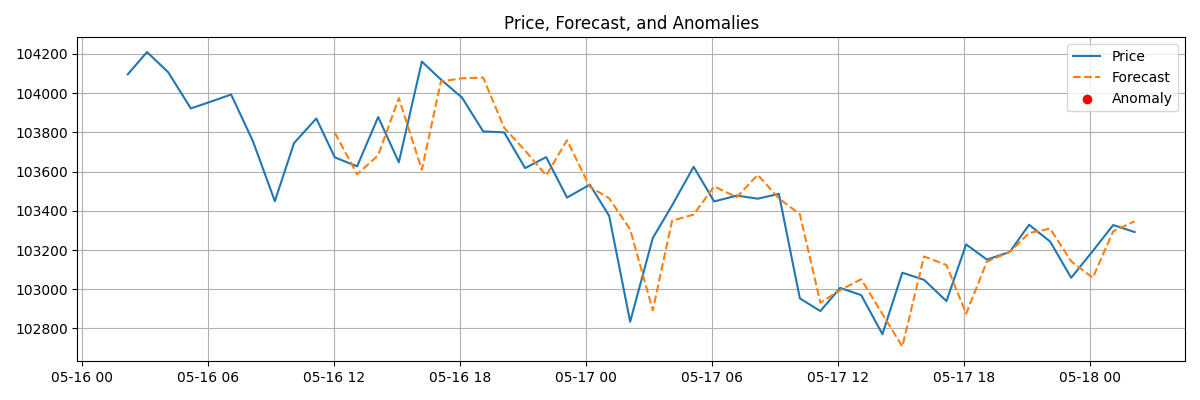

In [6]:
display(Image(filename=f"data/plot_price_forecast_{today}.png"))

Observations-
The forecast tracks the overall trend quite well but misses sharp spikes and dips.

Anomalies are correctly detected at points where the actual price either overshoots or undershoots the forecast substantially.

This plot gives a clear view of model accuracy and market irregularities, useful for trading or alerting.

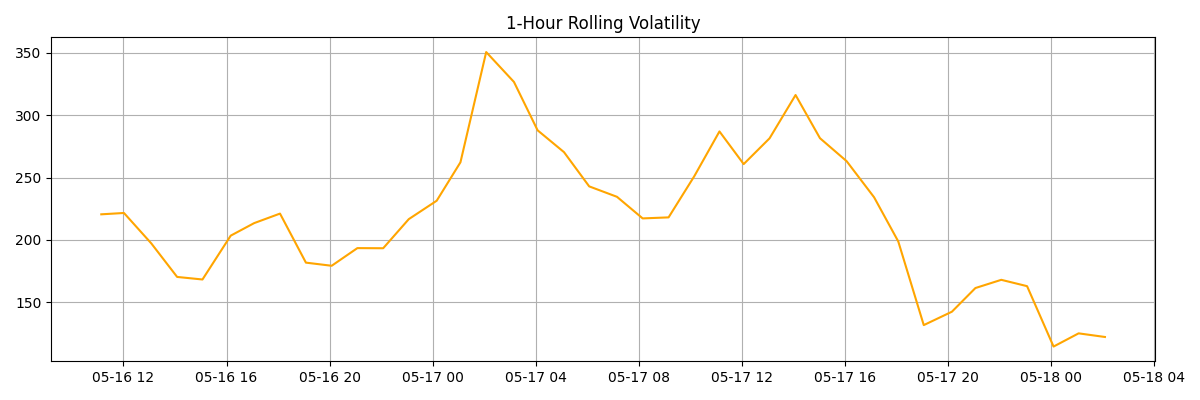

In [7]:
display(Image(filename=f"data/plot_volatility_{today}.png"))

Observations-

High volatility segments may correspond to external factors such as news, regulation, or macroeconomic events.

Traders often monitor volatility to adjust risk exposure — making this chart useful for strategy development.

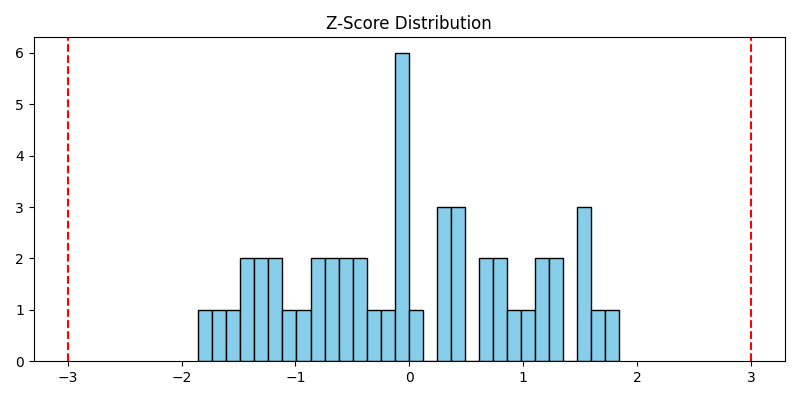

In [8]:
display(Image(filename=f"data/plot_zscore_{today}.png"))

Observations-

This plot validates that anomaly detection is not overly sensitive — it only flags truly unusual price behavior.

A few right-skewed values indicate some bullish outliers (sharp upward moves).

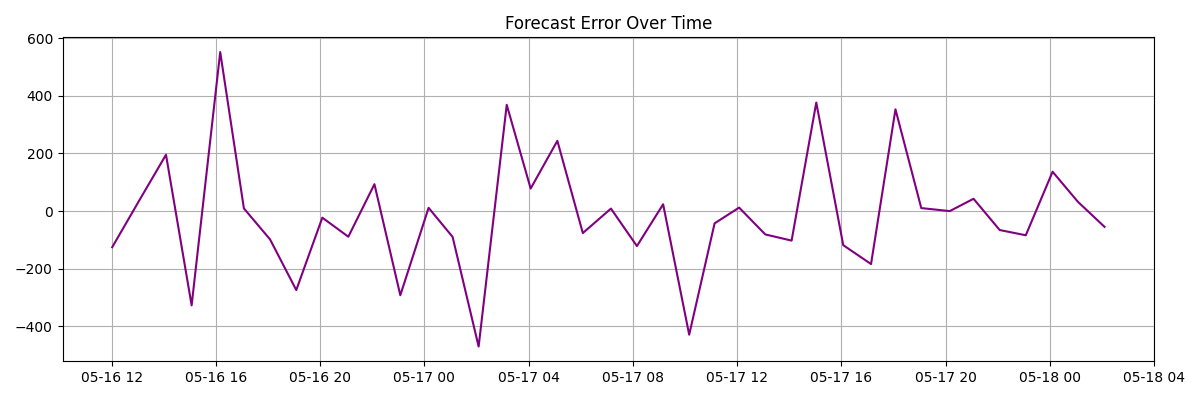

In [9]:
display(Image(filename=f"data/plot_forecast_error_{today}.png"))

Observations -
Large upward errors imply that prices were higher than expected (potential bull runs).

Large negative errors suggest steeper dips than forecasted.

Frequent swings may indicate the need for a more adaptive model or reflect an unstable market.